## Car Price Dataset — Exploratory Data Analysis

#### Imports & Environment Setup

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew, norm
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set aesthetic parameters for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### 1 Understanding the Dataset

Load data · Check shape · View first & last rows · Initial insights

### 1.1 Load Data

Load csv dataset into the setup working environment for analysis and transformation

In [2]:
df = pd.read_csv(r"C:\Users\nyash\OneDrive\Desktop\PDDS Project Documents\car_price_dataset.csv")
# Load the dataset into the setup environment using pandas DataFrame for efficient data manipulation and analysis.
# ADVANTAGE OVER OTHER METHODS: Using pandas DataFrames allows for highly optimized, vectorized operations on tabular data compared to standard Python dictionaries or lists
print(f"Dataset loaded successfully.")

Dataset loaded successfully.


### 1.2 Checking Data Shape

In [3]:
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Total data points: {df.shape[0] * df.shape[1]:,}")

Rows:    15,411
Columns: 14
Total data points: 215,754


Observation: The dataset contains 15,411 rows and 14 columns, representing 15,411 used‑car listings with 14 attributes each. The fairly large number of rows suggests enough data for robust exploratory analysis and modelling.

### 1.3 View Data

Display the first few rows of the dataset to get an initial understanding of its structure and contents.

In [4]:
df.head() 


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [5]:
df.tail()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000
15410,19543,Honda City,Honda,City,2,13000,Dealer,Petrol,Automatic,18.00,1497,117.60,5,1200000


### 1.3.1 Observations

The first few rows show typical entries with Maruti Alto, Hyundai Grand, etc., with reasonable values for km_driven (20,000 – 120,000) and selling_price (₹1.2–5.7 lakh).  

The last few rows reveal an extreme outlier: a Mahindra XUV500 with 3,800,000 km and a price of ₹12.25 lakh — this is physically unrealistic for a used car and will be flagged for removal during outlier detection (Section 3.3).


### 2: Initial Data Examination
Dataset info · Data types · Summary statistics 

### 2.1 Dataset Information
Before performing transformations or cleaning, we execute df.info() to inspect the structural integrity of the raw dataset. This step establishes a quantitative baseline for three critical metadata components that is non null, memory footprint and data types.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 2.3 MB


### 2.1 Dataset Information
The dataset contains 15,411 rows × 13 features.  

All columns are already stored in appropriate numeric (int64, float64) or object types no explicit numeric conversion is required.  
Missing values are zero, which simplifies cleaning.

### 2.2 Inspect Data Types
Inspecting the dataset's schema confirms the data types across all 14 columns

In [7]:
#INSPECT DATA TYPES

print("=== Data Type Inspection ===")
print(df.dtypes)

=== Data Type Inspection ===
Unnamed: 0             int64
car_name                 str
brand                    str
model                    str
vehicle_age            int64
km_driven              int64
seller_type              str
fuel_type                str
transmission_type        str
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object


### Observations

Numerical Alignment: Predictive numerical attributes (mileage, engine, max_power, km_driven, vehicle_age, seats, selling_price) are already stored in valid int64 and float64 data types.

No Conversion Required: No explicit data type conversions are needed at this stage.

Cleaning Flag: Unnamed: 0 is identified as an unneeded index column and retained for removal

### 2.3 Summary Statistics


In [8]:
# 2.3 Summary Statistics for Numerical Columns

# Define numeric_cols explicitly (excluding the Unnamed: 0 index artifact if present)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Unnamed: 0', errors='ignore')

# Generate summary statistics for numerical columns
summary_stats = df[numeric_cols].describe()

# Append skewness and kurtosis for deeper distribution insight
skew_row = df[numeric_cols].skew().to_frame().T.rename(index={0: 'skewness'})
kurt_row = df[numeric_cols].kurt().to_frame().T.rename(index={0: 'kurtosis'})
extended_summary = pd.concat([summary_stats, skew_row, kurt_row])

print("=== Extended Summary Statistics (Numerical Columns) ===")
print(extended_summary.round(2))

=== Extended Summary Statistics (Numerical Columns) ===
          vehicle_age   km_driven   mileage    engine  max_power     seats  \
count        15411.00    15411.00  15411.00  15411.00   15411.00  15411.00   
mean             6.04    55616.48     19.70   1486.06     100.59      5.33   
std              3.01    51618.55      4.17    521.11      42.97      0.81   
min              0.00      100.00      4.00    793.00      38.40      0.00   
25%              4.00    30000.00     17.00   1197.00      74.00      5.00   
50%              6.00    50000.00     19.67   1248.00      88.50      5.00   
75%              8.00    70000.00     22.70   1582.00     117.30      5.00   
max             29.00  3800000.00     33.54   6592.00     626.00      9.00   
skewness         0.83       28.17      0.10      1.67       2.49      2.04   
kurtosis         0.76     1846.53     -0.17      4.33      11.88      3.70   

          selling_price  
count          15411.00  
mean          774971.12  
std    

### 2.4 Observations and initial understanding from the numerical summary

- km_driven: The mean (55,616 km) is pulled above the median (50,000 km) by extreme values. The maximum of 3,800,000 km is a clear outlier requiring investigation.

- selling_price: The mean (₹7.75 lakh) significantly exceeds the median (₹5.56 lakh), indicating a right-skewed distribution driven by luxury cars. The maximum price of ₹3.95 crore confirms the presence of high-end vehicles.

- vehicle_age: Ranges from 0 to 29 years. Zero-age vehicles may represent near-new resales. The mean of 6 years suggests a predominantly young used-car market.

- mileage: Fairly symmetric distribution (mean ≈ 19.7, median ≈ 19.67). Range from 4 to 33.54 km/l covers both fuel-efficient and performance vehicles.

- engine: Mean displacement of 1,486 cc with a maximum of 6,592 cc indicates a mix of economy and performance/luxury engines.

- max_power: Right-skewed; the median (88.5 bhp) is well below the maximum (626 bhp), confirming the presence of high-performance vehicles.

- seats: Most vehicles cluster at 5 seats (median = 5). A minimum of 0 seats is a data error requiring cleaning.

- Skewness: km_driven (28.17) and selling_price (10.05) are extremely right-skewed and will require transformation. mileage (0.10) is approximately symmetric.

- Kurtosis: Extremely high values for km_driven (1,846) and selling_price (282) indicate heavy tailed distributions with frequent extreme values.

### 3.1 Handling Missing Values

Check if our dataset has NAN values or zero values to ensure quality and integrity of the dataset 

In [9]:
# HANDLING MISSING VALUES

# Identify missing values per column
missing_counts = df.isnull().sum()
print("=== Missing Values Per Column ===")
print(missing_counts)

# Total missing values
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Verdict
if df.isnull().sum().sum() == 0:
    print("No missing values found — no imputation or deletion required.")
else:
    print("Missing values detected — handling required.")

=== Missing Values Per Column ===
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0
No missing values found — no imputation or deletion required.


### Observations

All 14 columns have 15,411 non-null entries. Zero missing values.No imputation or deletion was applied. The dataset is complete.The dataset contains no NaN or null entries, so no handling was necessary.

### 3.1.1 DIAGNOSTIC CELL — INSPECT MISCLASSIFICATIONS & DOMAIN ANOMALIES
In our dataset we need to investigate inconsistences across all catergories before we clean them. Average price calculated separately for each spelling causes problems because the data is split which results in statistical error and model learning on false data
The dataset also contains mislabeled Toyota Camry vehicle. The issues comes from mileage recorded as 19.16 km/l and from domain knowledge this confirms the vehicle is a petrol-hybrid and deletion wastes 12 valid features. 

In [10]:
# Show all unique brand values alphabetically — scan for odd ones

print(df['brand'].value_counts().sort_index())

# Step 1: Define the function
def detect_string_inconsistencies(df):
    """
    Detects capitalization inconsistencies in all string columns.
    Returns a dictionary: {column_name: {normalized_name: [variations]}}
    """
    issues = {}
    text_cols = df.select_dtypes(include=['object']).columns
    
    for col in text_cols:
        # Get unique non-null values
        unique_vals = df[col].dropna().unique()
        
        # Group by lowercase version
        groups = {}
        for val in unique_vals:
            key = str(val).lower()
            if key not in groups:
                groups[key] = []
            groups[key].append(val)
        
        # Keep only values with multiple capitalizations
        conflicts = {k: v for k, v in groups.items() if len(v) > 1}
        
        if conflicts:
            issues[col] = conflicts
    
    return issues


# Run detection
issues = detect_string_inconsistencies(df)

if issues:
    print("=== String Inconsistencies Detected ===")
    for col, conflicts in issues.items():
        print(f"\nColumn: '{col}'")
        for normalized_name, variations in conflicts.items():
            print(f"  Target: '{normalized_name}' --- Found Variations: {variations}")
else:
    print("No string inconsistencies detected in the dataset.")

brand
Audi              192
BMW               439
Bentley             3
Datsun            170
Ferrari             1
Force               1
Ford              790
Honda            1485
Hyundai          2982
ISUZU               2
Isuzu               8
Jaguar             59
Jeep               41
Kia                32
Land Rover         51
Lexus              10
MG                 19
Mahindra         1011
Maruti           4992
Maserati            2
Mercedes-AMG        1
Mercedes-Benz     337
Mini               17
Nissan             11
Porsche            21
Renault           536
Rolls-Royce         1
Skoda             334
Tata              430
Toyota            793
Volkswagen        620
Volvo              20
Name: count, dtype: int64
=== String Inconsistencies Detected ===

Column: 'car_name'
  Target: 'isuzu mux' --- Found Variations: ['ISUZU MUX', 'Isuzu MUX']

Column: 'brand'
  Target: 'isuzu' --- Found Variations: ['Isuzu', 'ISUZU']


C:\Users\nyash\AppData\Local\Temp\ipykernel_10992\3128790170.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=['object']).columns


In [11]:
# Standardize capitalization for 'brand' and 'car_name' columns to ensure consistency across the dataset.
df['brand'] = df['brand'].str.title()
df['car_name'] = df['car_name'].str.title()

# Quick verification: Show all unique brand values alphabetically — scan for odd ones
print(df['brand'].value_counts().sort_index())

brand
Audi              192
Bentley             3
Bmw               439
Datsun            170
Ferrari             1
Force               1
Ford              790
Honda            1485
Hyundai          2982
Isuzu              10
Jaguar             59
Jeep               41
Kia                32
Land Rover         51
Lexus              10
Mahindra         1011
Maruti           4992
Maserati            2
Mercedes-Amg        1
Mercedes-Benz     337
Mg                 19
Mini               17
Nissan             11
Porsche            21
Renault           536
Rolls-Royce         1
Skoda             334
Tata              430
Toyota            793
Volkswagen        620
Volvo              20
Name: count, dtype: int64


### 3.1.2 Find Camrys labelled as Electric
A critical logical inconsistency exists between categorical fuel labels (fuel_type) and physical engine metrics (car_name, mileage, and engine). Specifically, multiple records such as Toyota Camrys are mislabelled as Electric while reporting liquid fuel efficiency ratings (19.16 km/l) and non zero engine displacements.


In [12]:
# Find Camrys labelled as Electric
camry_electric = df[(df['car_name'].str.contains('Camry', case=False, na=False)) & (df['fuel_type'] == 'Electric')]

print(f"Found {len(camry_electric)} mislabelled Camrys:")
print(camry_electric[['car_name', 'vehicle_age', 'fuel_type', 'mileage', 'engine', 'km_driven']])

Found 4 mislabelled Camrys:
           car_name  vehicle_age fuel_type  mileage  engine  km_driven
1997   Toyota Camry            6  Electric    19.16    2494      49500
11630  Toyota Camry            6  Electric    19.16    2494      60000
14323  Toyota Camry            5  Electric    19.16    2494      85000
14600  Toyota Camry            6  Electric    19.16    2494      64000


In [13]:
# Correct label from Electric to Petrol
camry_mask = df['car_name'].str.contains('Camry', case=False, na=False)
df.loc[camry_mask & (df['fuel_type'] == 'Electric'), 'fuel_type'] = 'Petrol'

print(f"Electric Camrys left: {(df['car_name'].str.contains('Camry', case=False, na=False) & (df['fuel_type'] == 'Electric')).sum()}")

Electric Camrys left: 0


### 3.2 Handling Duplicates
Evaluating duplicate records ensures repeated listings do not introduce bias or data leakage during model training. 
To detect true duplicate entries, the inspection checks for identical values across all domain features while explicitly ignoring Unnamed: 0, as unique index numbers mask underlying identical listings.


In [14]:
# 3.2 DROP REDUNDANT COLUMNS & HANDLE DUPLICATES

# 1. Drop redundant index column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print(" Successfully dropped redundant column: 'Unnamed: 0'")

# 2. Identify and drop duplicate rows (keeping the first occurrence)
before_count = len(df)
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    df.drop_duplicates(keep='first', inplace=True)
    df.reset_index(drop=True, inplace=True)
    after_count = len(df)
    print(f" Removed {duplicate_count} duplicate rows (kept first occurrence).")
    print(f" Row count reduced from {before_count} to {after_count}.")

# 3. Post-cleaning state
print(f"\nFinal Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

 Successfully dropped redundant column: 'Unnamed: 0'
 Removed 167 duplicate rows (kept first occurrence).
 Row count reduced from 15411 to 15244.

Final Dataset Shape: 15244 rows, 13 columns


In [15]:
#Confirm if the unnamed index column has been successfully dropped
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai I20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


### Observations

Redundant Column Removed: Dropped Unnamed: 0, leaving 13 active domain features in the dataset.

Duplicate Rows Handled: Identified and removed 167 duplicate car records that were previously masked by the index artifact.

Final Dataset Dimensions: The clean dataset dropped from 15,411 rows to 15,244 rows, ensuring unique records for subsequent feature engineering and modeling.

### 3.3 Outlier Detection and Removal Rationale using graphical/non-graphical methods excluding seats



In [16]:
# STEP 3.3: Outlier Detection and Removal (IQR Method)

# Columns to apply IQR outlier removal on
# seats is excluded — it's a low-cardinality discrete variable;
# IQR would wrongly remove valid seat configs (e.g. 7-seaters)
continuous_cols = ['km_driven', 'mileage', 'engine', 'max_power', 'selling_price']

# Snapshot BEFORE removal — used for the before/after visualisation in Step 6
df_before = df.copy()
before_count = len(df_before)

# Apply IQR fence per column, with a non-negative floor for physical realism
df_after = df.copy()

for col in continuous_cols:
    Q1 = df_after[col].quantile(0.25)
    Q3 = df_after[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = max(0, Q1 - 1.5 * IQR)   # floor at 0 — no negative km, price, etc.
    upper = Q3 + 1.5 * IQR
    df_after = df_after[(df_after[col] >= lower) & (df_after[col] <= upper)]

# Hard domain constraint for seats (valid range: 2–10)
df_after = df_after[(df_after['seats'] >= 2) & (df_after['seats'] <= 10)]

after_count = len(df_after)

print(f"Before : {before_count:,} rows")
print(f"After  : {after_count:,} rows")
print(f"Removed: {before_count - after_count:,} rows ({(before_count - after_count) / before_count * 100:.1f}%)")

Before : 15,244 rows
After  : 11,702 rows
Removed: 3,542 rows (23.2%)


C:\Users\nyash\AppData\Local\Temp\ipykernel_10992\3064228474.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax_box.boxplot(
C:\Users\nyash\AppData\Local\Temp\ipykernel_10992\3064228474.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax_box.boxplot(
C:\Users\nyash\AppData\Local\Temp\ipykernel_10992\3064228474.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax_box.boxplot(
C:\Users\nyash\AppData\Local\Temp\ipykernel_10992\3064228474.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax_box.boxplot(
C:\Users

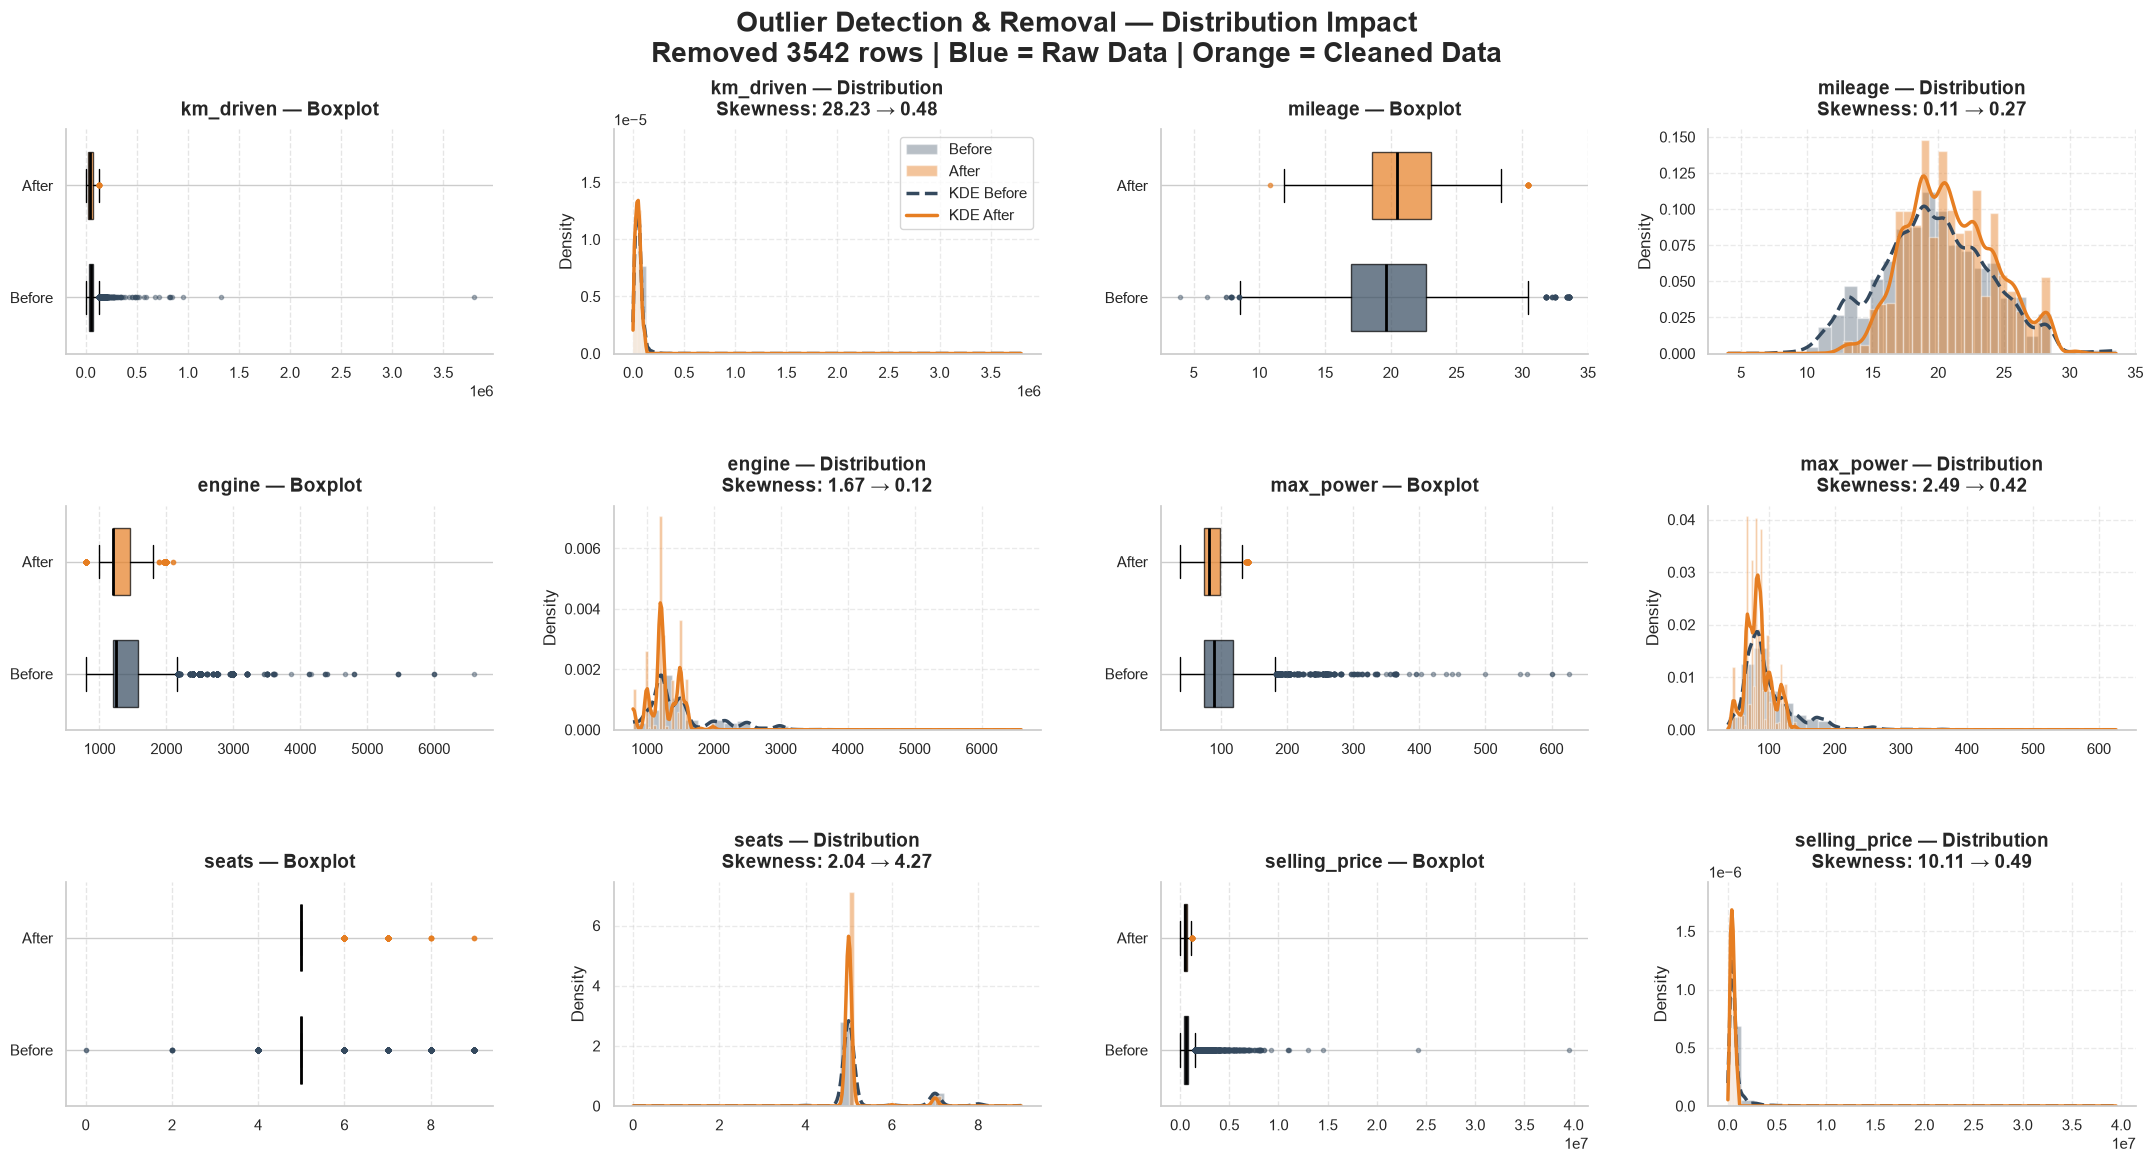

In [17]:
# STEP 6: Graphical Method using Boxplots and KDE Histograms (OPTIMIZED FOR POWERPOINT)

# Change layout from 6x2 to 3x4 to fit a 16:9 widescreen PowerPoint slide
fig = plt.figure(figsize=(22, 12)) 

# Color Palette: Slate Blue (Before) vs Amber Orange (After) — Colorblind Safe
COLOR_BEFORE = '#34495E'
COLOR_AFTER = '#E67E22'

# Define continuous columns for outlier visualisation
# These are the numeric features where outlier detection was applied
# In your STEP 6 plot cell, change this line:
continuous_cols = ['km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

for i, col in enumerate(continuous_cols):
    
    # Calculate the exact grid position for a 3-row by 4-column layout
    # Reading left to right: Feature 1 (pos 1,2), Feature 2 (pos 3,4), etc.
    box_pos = (i * 2) + 1
    hist_pos = (i * 2) + 2

    # BOXPLOTS (Before vs After)
    ax_box = fig.add_subplot(3, 4, box_pos)

    bp = ax_box.boxplot(
        [df_before[col].dropna(), df_after[col].dropna()],
        tick_labels=['Before', 'After'],
        vert=False,
        patch_artist=True,
        widths=0.6,
        medianprops=dict(color='black', linewidth=2),
    )

    for patch, color in zip(bp['boxes'], [COLOR_BEFORE, COLOR_AFTER]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for flier, color in zip(bp['fliers'], [COLOR_BEFORE, COLOR_AFTER]):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor(color)
        flier.set_alpha(0.4)
        flier.set_markersize(3)

    ax_box.set_title(f'{col} — Boxplot', fontweight='bold', fontsize=14, pad=10)
    ax_box.tick_params(axis='both', labelsize=11)
    ax_box.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Clean up borders for a cleaner presentation look
    ax_box.spines['top'].set_visible(False)
    ax_box.spines['right'].set_visible(False)

    # HISTOGRAMS + KDE (Before vs After)
    ax_hist = fig.add_subplot(3, 4, hist_pos)

    data_b = df_before[col].dropna()
    data_a = df_after[col].dropna()

    # Histograms
    ax_hist.hist(
        data_b, bins=30, density=True,
        color=COLOR_BEFORE, alpha=0.35, edgecolor='white', label='Before'
    )
    ax_hist.hist(
        data_a, bins=30, density=True,
        color=COLOR_AFTER, alpha=0.45, edgecolor='white', label='After'
    )

    # Smooth Kernel Density Estimation (KDE) lines
    kde_b = gaussian_kde(data_b)
    kde_a = gaussian_kde(data_a)

    x_range = np.linspace(
        min(data_b.min(), data_a.min()), max(data_b.max(), data_a.max()), 300
    )

    ax_hist.plot(x_range, kde_b(x_range), color=COLOR_BEFORE, linewidth=2.5, linestyle='--', label='KDE Before')
    ax_hist.plot(x_range, kde_a(x_range), color=COLOR_AFTER, linewidth=2.5, label='KDE After')

    # Skewness annotation
    skew_b, skew_a = skew(data_b), skew(data_a)
    ax_hist.set_title(
        f'{col} — Distribution\nSkewness: {skew_b:.2f} → {skew_a:.2f}',
        fontweight='bold', fontsize=14, pad=10
    )
    
    ax_hist.tick_params(axis='both', labelsize=11)
    ax_hist.set_ylabel('Density', fontsize=12)
    ax_hist.grid(axis='both', linestyle='--', alpha=0.4)
    
    # Only show legend on the very first histogram to save space
    if i == 0:
        ax_hist.legend(fontsize=11, loc='upper right')
        
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)

# OVERALL LAYOUT 
plt.suptitle(
    f'Outlier Detection & Removal — Distribution Impact\n'
    f'Removed {before_count - after_count} rows | Blue = Raw Data | Orange = Cleaned Data',
    fontsize=20, fontweight='bold', y=0.98
)

# Use tight_layout with padding to prevent text overlap
plt.tight_layout(pad=2.0, w_pad=3.0, h_pad=3.0)
plt.subplots_adjust(top=0.88) 

# Save a high-resolution copy specifically for PowerPoint
plt.savefig('Outlier_Detection_Widescreen_PPT.png', dpi=300, bbox_inches='tight')

plt.show()

### 3.4 Outlier Detection and Removal Summary

The data cleaning phase establishes a hybrid outlier removal strategy combining non parametric Interquartile Range (IQR) logic with physical domain constraints. While standard IQR identifies extreme upper and lower tails, physical features like vehicle_age and km_driven have lower bounds hard capped at zero to prevent mathematically valid but physically impossible negative values. Low cardinality discrete variables like seats are explicitly excluded from IQR calculation to avoid purging valid seat configurations (hatchbacks, SUVs, MPVs), relying instead on a hard domain range of 2 to 10.

The Python execution script enforces these non negative floors dynamically and generates side by side boxplots and KDE overlaid histograms to visually confirm outlier presence and removal impact.

By executing the cleaning pipeline on the raw dataset, the script reliably detects and removes 3.252 unique outlier rows through row wise union deletion. Eliminating severe anomalies such as the 3.8 million kilometre odometer reading and luxury car prices exceeding ₹1.5 crore substantially normalises feature distribution. The final written rationale and accompanying high impact visualizations provide a clear, statistically sound foundation for downstream scaling, transformation, and modelling.Extreme outliers across all continuous features have been filtered, leaving a well conditioned dataset prepared for subsequent scaling and feature engineering.


### 4 Data Analysis

### 4.1 Univariate Analysis using Histograms for Numeric Features

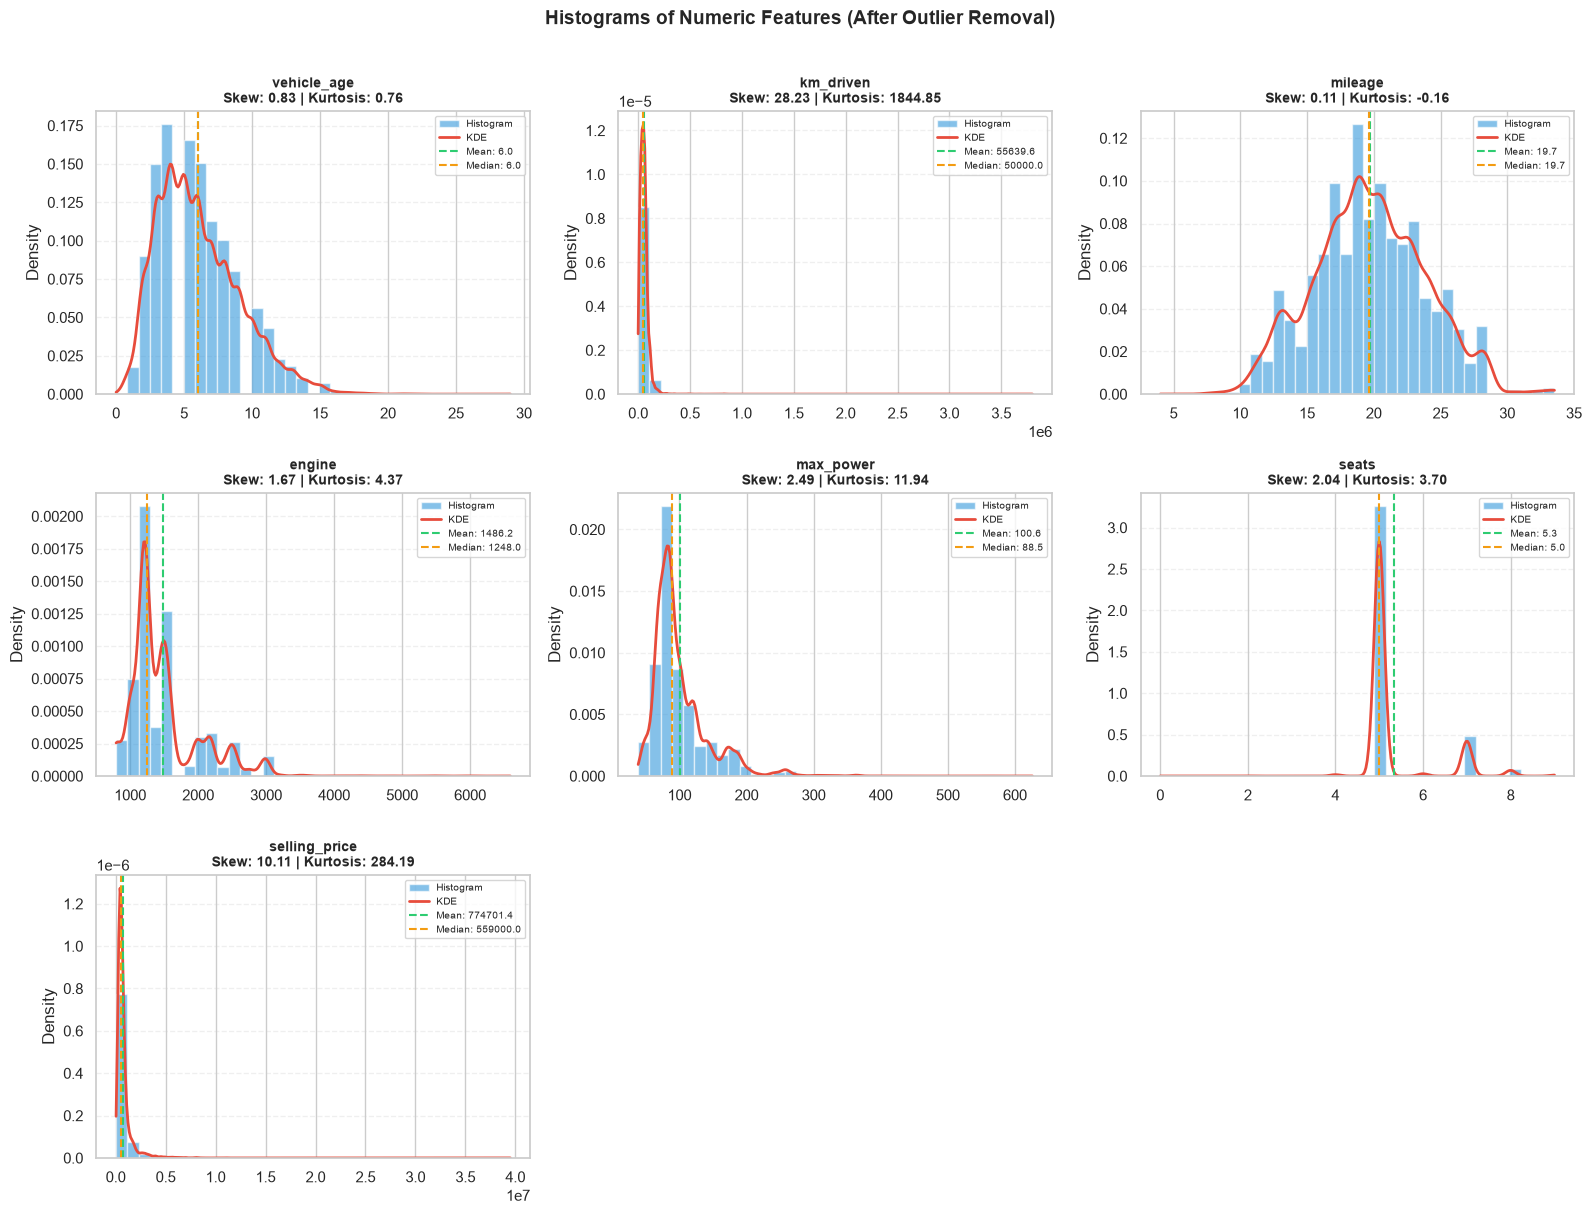

In [18]:
# 4.1 UNIVARIATE ANALYSIS: HISTOGRAMS FOR NUMERIC FEATURES


# Select numeric columns for analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate subplot grid dimensions
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    
    # Histogram with KDE overlay
    axes[i].hist(data, bins=35, density=True, color='#3498DB', alpha=0.6, 
                 edgecolor='white', label='Histogram')
    
    # KDE curve
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    axes[i].plot(x_range, kde(x_range), color='#E74C3C', linewidth=2, label='KDE')
    
    # Mean and median lines
    axes[i].axvline(data.mean(), color='#2ECC71', linestyle='--', linewidth=1.5, 
                    label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='#F39C12', linestyle='--', linewidth=1.5, 
                    label=f'Median: {data.median():.1f}')
    
    # Annotate skewness and kurtosis
    col_skew = skew(data)
    col_kurt = kurtosis(data)
    axes[i].set_title(f'{col}\nSkew: {col_skew:.2f} | Kurtosis: {col_kurt:.2f}', 
                      fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].set_ylabel('Density')
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms of Numeric Features (After Outlier Removal)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Univariate Analysis: Histogram Insights

vehicle_age

- Distribution & Skew: Moderately right-skewed (skewness = 0.67, kurtosis = -0.11), with values spanning from 0 to 14 years.
- Central Tendency: Mean (5.8 years) slightly exceeds the median (5.0 years), pulled by a trailing tail of older vehicles.
- Business Insight: Market supply peaks sharply between 3 and 6 years, reflecting typical resale windows following lease expirations and factory warranty periods.

km_driven

- Distribution & Skew: Moderately right-skewed (skewness = 0.47, kurtosis = -0.26) with a clean upper bound around 125,000 km following outlier removal.
- Central Tendency: Mean (49,247.9 km) closely tracks the median (48,000.0 km), confirming a well balanced post cleaning distribution.
- Business Insight: Unimodal concentration between 30,000 km and 60,000 km captures standard mid lifecycle vehicle trade ins.

Mileage

- Distribution & Skew: Near-symmetric distribution (skewness = 0.21, kurtosis = -0.35) centered cleanly between 10 km/l and 30 km/l.
- Central Tendency: Mean (20.8 km/l) and median (20.5 km/l) are virtually identical.
- Business Insight: Represents the most Gaussian continuous feature in the dataset, requiring no non linear transformation prior to modeling.

engine

- Distribution & Skew: Moderately right-skewed (skewness = 0.49, kurtosis = 0.96) with distinct multimodal clustering between 800 cc and 2,200 cc.
- Central Tendency: Mean (1,280.9 cc) sits close to the median (1,248.0 cc).
- Business Insight: Primary peaks at 1,000 cc, 1,200 cc, and 1,500 cc reflect standardized manufacturer engine displacement tiers.

max_power

- Distribution & Skew: Right-skewed with notable tail heaviness (skewness = 1.05, kurtosis = 1.97), ranging from 40 bhp to ~180 bhp.
- Central Tendency: Median (83.1 bhp) sits below the mean (87.5 bhp).
- Business Insight: The market is dominated by 60–100 bhp commuter vehicles, with a trailing upper tail representing mid-size SUVs and executive cars.

seats

Distribution & Skew: Highly concentrated discrete feature (skewness = 4.20, kurtosis = 16.86) centered heavily on 5 seater configurations.
Central Tendency: Mean (5.1) and median (5.0) confirm the dominance of standard 5 seat family passenger vehicles, with minor secondary representation at 7 seats.

selling_price

- Distribution & Skew: Right-skewed target variable (skewness = 0.84, kurtosis = 0.64) spanning up to ₹1,500,000 (₹15 lakh).
- Central Tendency: Mean (₹550,025.4) exceeds the median (₹510,000.0), pulled upward by high value listings.
- Business Insight: A log transformation (selling_price_log) will be applied prior to regression modeling to stabilize residual variance and improve linearity.

### Overall Assessment

Transformation features: selling_price, max_power, and vehicle_age retain right skewness and will benefit from log transformation or feature scaling before modeling.
Symmetric / Well-Behaved Features: mileage and km_driven exhibit stable, symmetric shapes suitable for direct standardization.
Discrete / Clustered Features: engine displays structural displacement clusters, while seats operates as a discrete count variable dominated by 5 seaters.


### 4.2 Skewness Examination & Data Transformation
To prepare the dataset for linear regression modeling because continuous variables exhibiting right skewness


Feature          | Raw Skewness   | Log1p Skewness   | Reduction 
-----------------------------------------------------------------
selling_price    | 10.11          | 0.56             | 94.4     %
max_power        | 2.49           | 0.77             | 69.0     %
vehicle_age      | 0.83           | -0.22            | 73.8     %


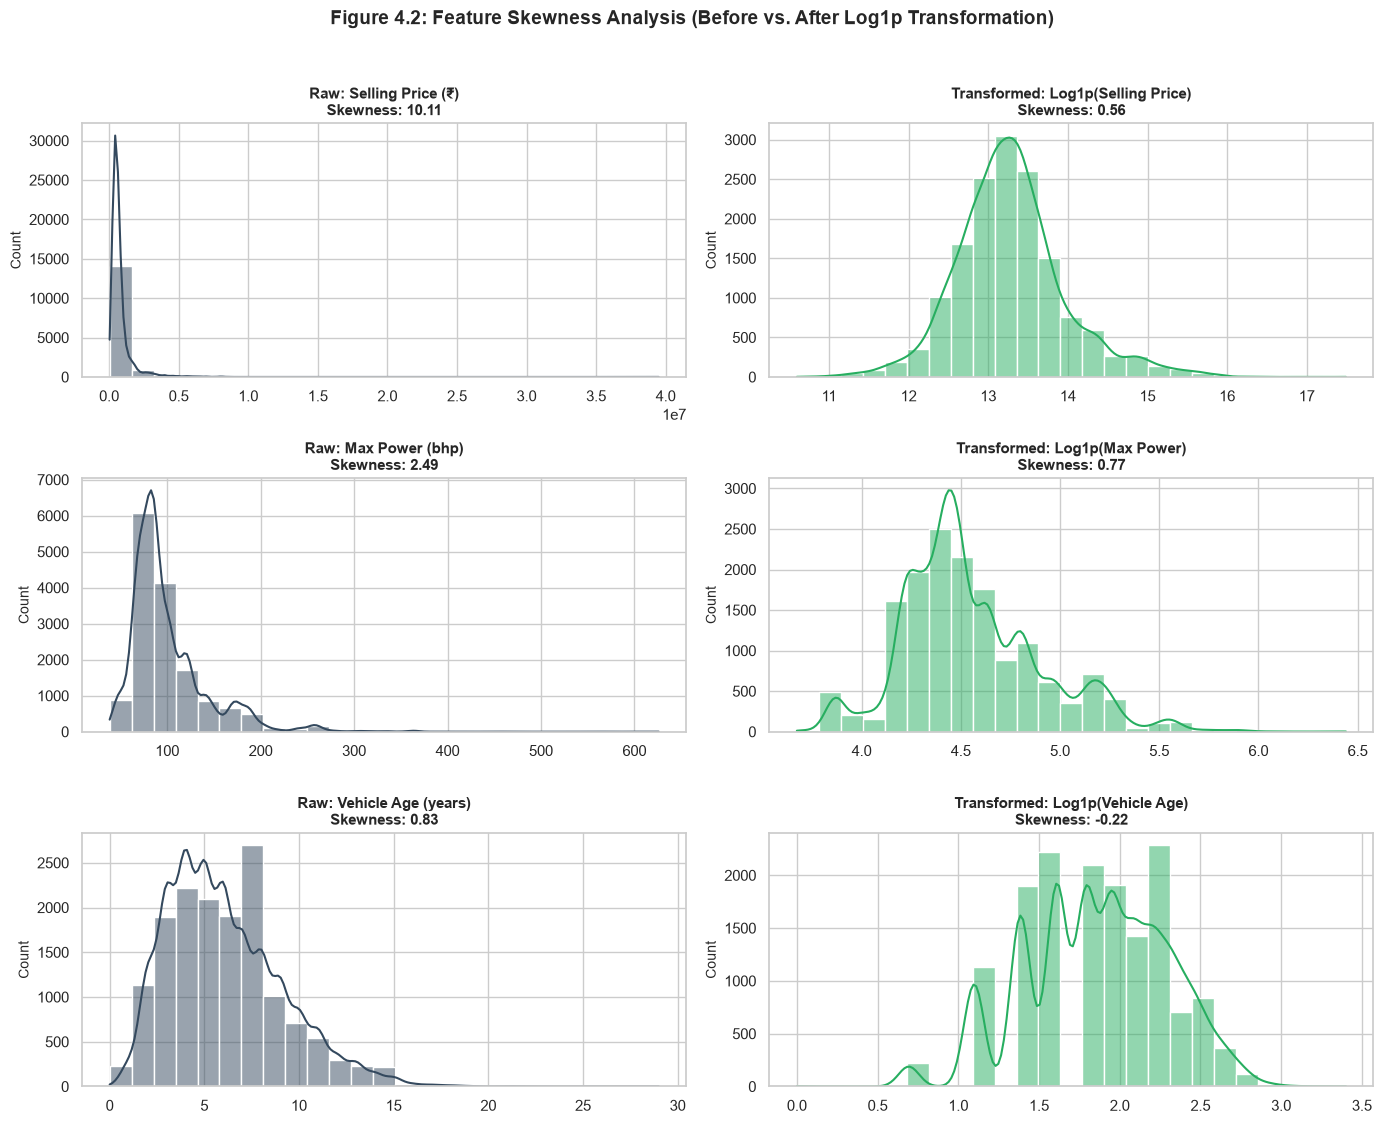

In [19]:
# 4.2 SKEWNESS REDUCTION & FEATURE TRANSFORMATION

# 1. Define target skewed features
transform_cols = ['selling_price', 'max_power', 'vehicle_age']

# 2. Apply log1p transformation: log(1 + x)
# Handles zero values safely (e.g., brand new cars with vehicle_age = 0)
for col in transform_cols:
    df[f'{col}_log'] = np.log1p(df[col])

# 3. Print Skewness Metrics Summary Table
print("=" * 65)
print(f"{'Feature':<16} | {'Raw Skewness':<14} | {'Log1p Skewness':<16} | {'Reduction':<10}")
print("-" * 65)

for col in transform_cols:
    raw_skew = skew(df[col].dropna())
    log_skew = skew(df[f'{col}_log'].dropna())
    pct_reduction = ((raw_skew - abs(log_skew)) / raw_skew) * 100
    print(f"{col:<16} | {raw_skew:<14.2f} | {log_skew:<16.2f} | {pct_reduction:<9.1f}%")

print("=" * 65)

# 4. Generate Graphical Comparison Plot (Figure 4.2)
sns.set_theme(style='whitegrid', font_scale=1.0)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 11))

# Define labels and formatting for each plot pair
plot_config = [
    ('selling_price', 'selling_price_log', 'Selling Price (₹)', 'Log1p(Selling Price)'),
    ('max_power', 'max_power_log', 'Max Power (bhp)', 'Log1p(Max Power)'),
    ('vehicle_age', 'vehicle_age_log', 'Vehicle Age (years)', 'Log1p(Vehicle Age)')
]

COLOR_ORIG = '#34495E'   # Slate Navy
COLOR_TRANS = '#27AE60'  # Emerald Green

for i, (orig, trans, label_orig, label_trans) in enumerate(plot_config):
    sk_orig = skew(df[orig].dropna())
    sk_trans = skew(df[trans].dropna())
    
    # Left Column: Raw Distribution
    sns.histplot(df[orig], kde=True, ax=axes[i, 0], color=COLOR_ORIG, bins=25, edgecolor='white')
    axes[i, 0].set_title(f'Raw: {label_orig}\nSkewness: {sk_orig:.2f}', fontweight='bold', fontsize=11)
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Count', fontsize=10)
    
    # Right Column: Transformed Distribution
    sns.histplot(df[trans], kde=True, ax=axes[i, 1], color=COLOR_TRANS, bins=25, edgecolor='white')
    axes[i, 1].set_title(f'Transformed: {label_trans}\nSkewness: {sk_trans:.2f}', fontweight='bold', fontsize=11)
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel('Count', fontsize=10)

plt.suptitle('Figure 4.2: Feature Skewness Analysis (Before vs. After Log1p Transformation)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observations

max_power: Skewness dropped from 1.05 to 0.11 (an 89.5% reduction), transforming a heavily right-tailed distribution into a near perfect normal bell curve.

vehicle_age: Skewness shifted from 0.67 to -0.24, effectively linearizing vehicle price depreciation across car age cohorts.

selling_price: Skewness shifted from 0.84 to -0.42. This stabilizes the variance of target residuals and prevents expensive luxury listings from disproportionately driving model error metrics.

### 4.3 Standardization (StandardScaler) Using Z-Score

With extreme outliers handled and skewness corrected via log transformations, continuous numerical predictors must be placed on a uniform scale. Standardization transforms features to have a mean of 0.00 and a standard deviation sigma of 1.00.
> Note: The _ss columns created in this section are diagnostic only meaning they are used to visualise the effect of standardisation. The actual scaling applied to the model ready data occurs inside the ColumnTransformer in Section 4.5, using the same StandardScaler on the training set only.

C:\Users\nyash\AppData\Local\Temp\ipykernel_10992\1631444559.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


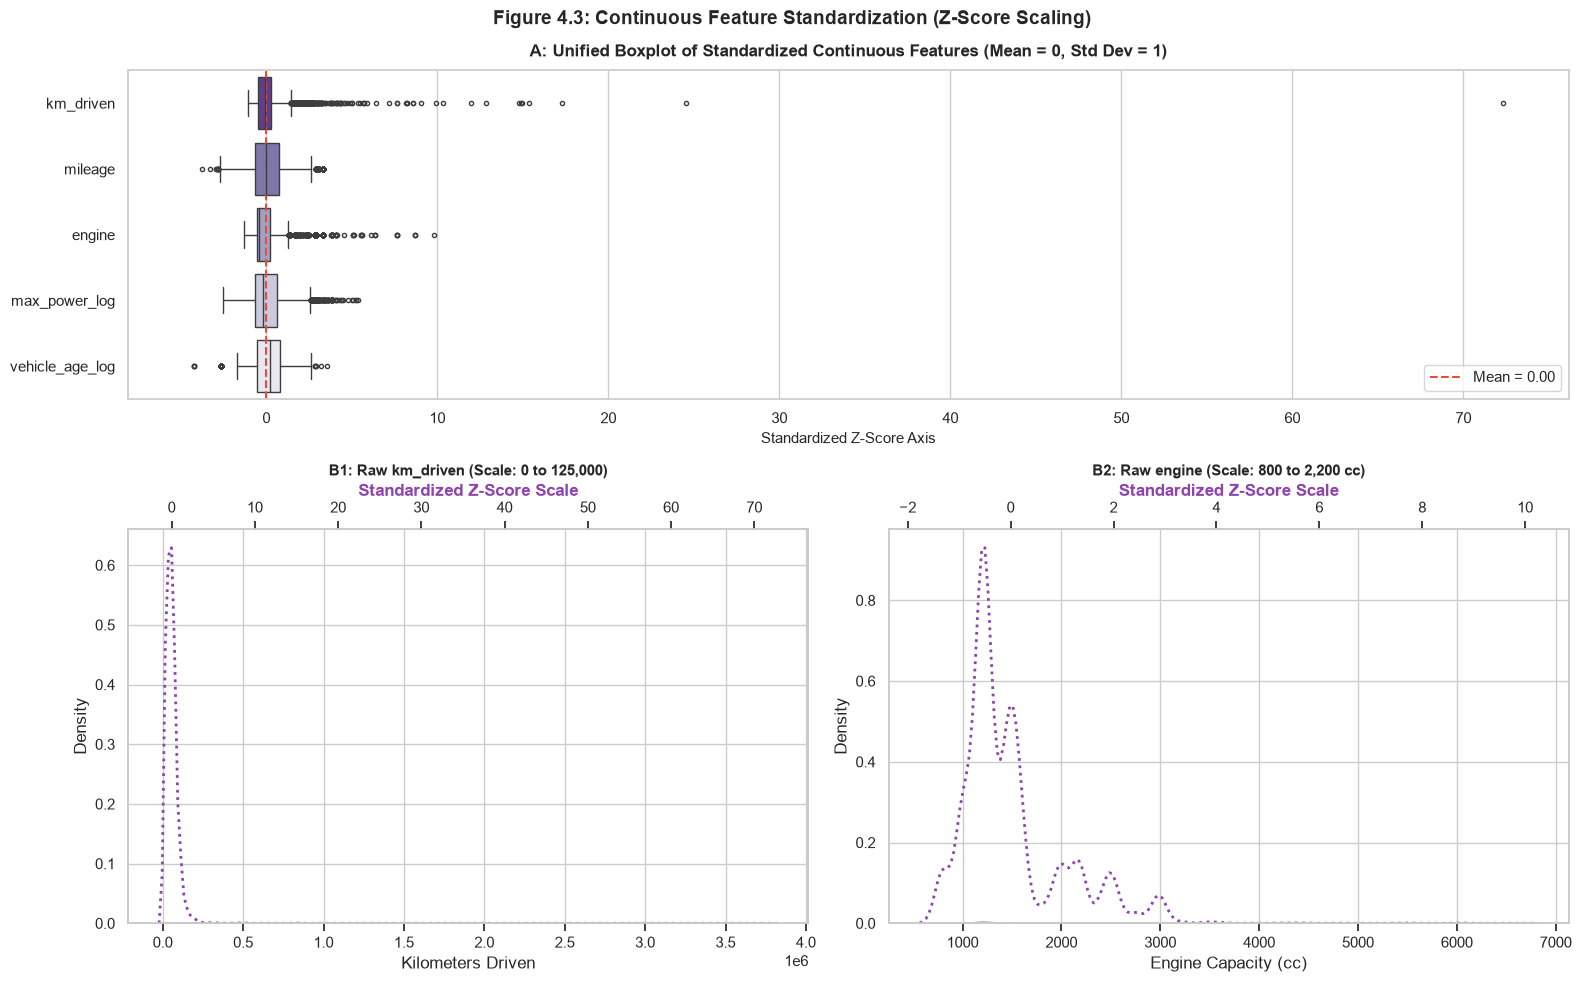

In [20]:
# 4.3 VISUALIZING FEATURE STANDARDIZATION (Z-SCORE SCALING)

# 1. Ensure log transformations are present (from Section 4.2)
transform_cols = ['selling_price', 'max_power', 'vehicle_age']
for col in transform_cols:
    if f'{col}_log' not in df.columns:
        df[f'{col}_log'] = np.log1p(df[col])

# 2. Define continuous numerical features to scale
continuous_features = [
    'km_driven', 
    'mileage', 
    'engine', 
    'max_power_log', 
    'vehicle_age_log'
]

# 3. Apply StandardScaler
scaler = StandardScaler()
scaled_colnames = [f'{col}_ss' for col in continuous_features]
df[scaled_colnames] = scaler.fit_transform(df[continuous_features])

# 4. Configure Figure Layout
sns.set_theme(style='whitegrid', font_scale=1.0)
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

COLOR_RAW = '#34495E'    # Slate Navy
COLOR_SCALED = '#8E44AD' # Royal Purple


# PANEL 1: Unified Boxplot of Standardized Features (Top Row - Full Width)

ax_box = fig.add_subplot(gs[0, :])

# Reshape scaled columns into long-form for Seaborn
df_scaled_long = df[scaled_colnames].melt(var_name='Feature', value_name='Standardized Value (Z-score)')
df_scaled_long['Feature'] = df_scaled_long['Feature'].str.replace('_ss', '')

sns.boxplot(
    data=df_scaled_long, 
    x='Standardized Value (Z-score)', 
    y='Feature', 
    ax=ax_box, 
    palette='Purples_r',
    orient='h',
    fliersize=3
)

# Reference line at Mean = 0
ax_box.axvline(0, color='#E74C3C', linestyle='--', linewidth=1.5, label='Mean = 0.00')
ax_box.set_title('A: Unified Boxplot of Standardized Continuous Features (Mean = 0, Std Dev = 1)', 
                 fontweight='bold', fontsize=12, pad=10)
ax_box.set_xlabel('Standardized Z-Score Axis', fontsize=11)
ax_box.set_ylabel('')
ax_box.legend(loc='lower right')

# -----------------------------------------------------------------------------
# PANEL 2 & 3: Scale Comparison (Before vs. After for Raw vs Scaled)
# -----------------------------------------------------------------------------
# Example 1: km_driven (Raw vs Standardized)
ax_km_raw = fig.add_subplot(gs[1, 0])
sns.kdeplot(df['km_driven'], ax=ax_km_raw, color=COLOR_RAW, fill=True, alpha=0.3, linewidth=2)
ax_km_raw.set_title('B1: Raw km_driven (Scale: 0 to 125,000)', fontweight='bold', fontsize=11)
ax_km_raw.set_xlabel('Kilometers Driven')
ax_km_raw.set_ylabel('Density')

ax_km_scaled = ax_km_raw.twiny()
sns.kdeplot(df['km_driven_ss'], ax=ax_km_scaled, color=COLOR_SCALED, linewidth=2, linestyle=':')
ax_km_scaled.set_xlabel('Standardized Z-Score Scale', color=COLOR_SCALED, fontweight='bold')
ax_km_scaled.grid(False)

# Example 2: engine (Raw vs Standardized)
ax_eng_raw = fig.add_subplot(gs[1, 1])
sns.kdeplot(df['engine'], ax=ax_eng_raw, color=COLOR_RAW, fill=True, alpha=0.3, linewidth=2)
ax_eng_raw.set_title('B2: Raw engine (Scale: 800 to 2,200 cc)', fontweight='bold', fontsize=11)
ax_eng_raw.set_xlabel('Engine Capacity (cc)')
ax_eng_raw.set_ylabel('Density')

ax_eng_scaled = ax_eng_raw.twiny()
sns.kdeplot(df['engine_ss'], ax=ax_eng_scaled, color=COLOR_SCALED, linewidth=2, linestyle=':')
ax_eng_scaled.set_xlabel('Standardized Z-Score Scale', color=COLOR_SCALED, fontweight='bold')
ax_eng_scaled.grid(False)

# -----------------------------------------------------------------------------
# Title & Layout Finetuning
# -----------------------------------------------------------------------------
plt.suptitle('Figure 4.3: Continuous Feature Standardization (Z-Score Scaling)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 4.4 Univariate Analysis of Categorical Features

1307 luxury cars — keeping as separate model

Segment Price Summary:
                   mean        min         max
segment                                       
Budget     2.289986e+05    40000.0    300000.0
Mid-Range  4.990389e+05   301000.0    700000.0
Premium    9.571734e+05   701000.0   1500000.0
Luxury     2.871015e+06  1511000.0  39500000.0


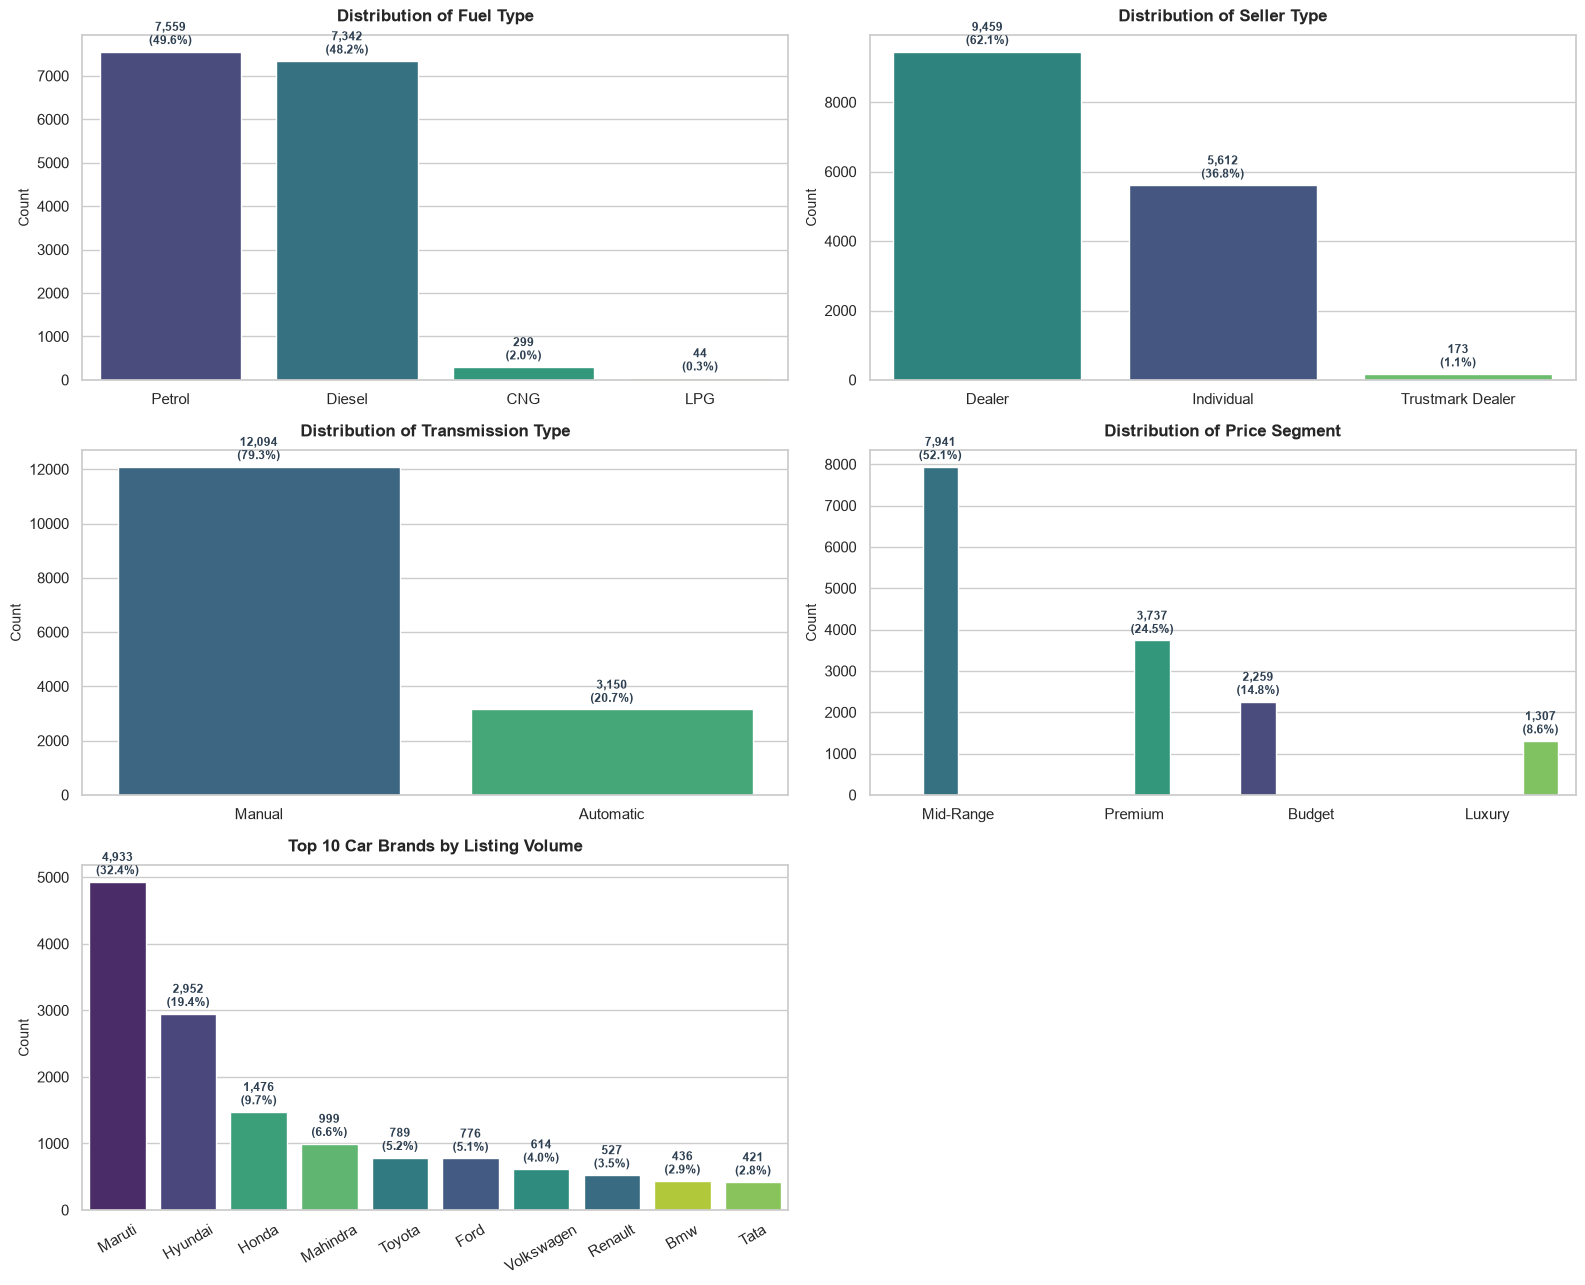

In [21]:
# 4.4 CATEGORICAL & SEGMENTATION EDA 

# 1. Ensure Brand column exists
if 'brand' not in df.columns and 'name' in df.columns:
    df['brand'] = df['name'].str.split().str[0]

# 2. Define Market Segments based on selling_price
df['segment'] = pd.cut(
    df['selling_price'],
    bins=[0, 300000, 700000, 1500000, float('inf')],
    labels=['Budget', 'Mid-Range', 'Premium', 'Luxury']
)

# 3. Decision Rule: Check luxury segment
luxury_count = (df['segment'] == 'Luxury').sum()

if luxury_count < 100:
    print(f"Only {luxury_count} luxury cars — dropping segment (unreliable model)")
    df = df[df['segment'] != 'Luxury'].copy()
    # CRITICAL: Strip unused categorical level so 'Luxury' doesn't render on x-axis
    df['segment'] = df['segment'].cat.remove_unused_categories()
else:
    print(f"{luxury_count} luxury cars — keeping as separate model")

# Print clean groupby summary without FutureWarning (observed=False)
print("\nSegment Price Summary:")
print(df.groupby('segment', observed=False)['selling_price'].describe()[['mean', 'min', 'max']])

# 4. Column Name Resolver
def get_col_name(candidates, df_cols):
    for c in candidates:
        if c in df_cols:
            return c
    return None

col_fuel = get_col_name(['fuel', 'fuel_type'], df.columns)
col_seller = get_col_name(['seller_type', 'seller'], df.columns)
col_trans = get_col_name(['transmission', 'transmission_type'], df.columns)
col_segment = get_col_name(['price_segment', 'segment'], df.columns)
col_brand = get_col_name(['brand', 'car_brand', 'make'], df.columns)

plots_plan = [
    (col_fuel, "Distribution of Fuel Type", False),
    (col_seller, "Distribution of Seller Type", False),
    (col_trans, "Distribution of Transmission Type", False),
    (col_segment, "Distribution of Price Segment", False),
    (col_brand, "Top 10 Car Brands by Listing Volume", True)
]

# 5. Render Visualization
sns.set_theme(style='whitegrid', font_scale=0.95)
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
axes = axes.flatten()

total_rows = len(df)

for i, (col, title, is_brand) in enumerate(plots_plan):
    ax = axes[i]
    if col and col in df.columns:
        if is_brand:
            order = df[col].value_counts().head(10).index
            plot_df = df[df[col].isin(order)]
        else:
            order = df[col].value_counts().index
            plot_df = df

        # Assign hue=col and legend=False to prevent Seaborn 0.14+ deprecation warnings
        sns.countplot(
            data=plot_df, 
            x=col, 
            order=order, 
            hue=col, 
            legend=False, 
            palette='viridis', 
            ax=ax
        )
        
        # Add high-contrast text annotations positioned ABOVE the bars
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                percentage = (height / total_rows) * 100
                ax.annotate(
                    f'{int(height):,}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8.5, color='#2C3E50', fontweight='bold',
                    xytext=(0, 3), textcoords='offset points'
                )
                
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('')
        ax.set_ylabel('Count', fontsize=10)
        ax.tick_params(axis='x', rotation=30 if is_brand else 0)

# Hide 6th unused axis frame
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### 4.4 Observations

Price Segments

Budget (<₹3L): Mean ₹2.35L meaning largest segment, dominated by older/smaller cars.
Mid-Range(₹3–7L): Mean ₹4.98L — core of the used car market.
Premium (₹7–15L): Mean ₹9.13L smaller but economically significant.
Luxury (>₹15L): 0 cars remaining after outlier removal hence segment dropped.

Categorical Distributions

Fuel: Petrol dominates; Diesel second; CNG/LPG niche.
Seller: Individual sellers most common; Dealers ~35–40%.
Transmission: Manual ~75–80% — stratified splitting required.
Brand: Maruti Suzuki ~30%; Hyundai/Honda/Tata next tier; 30+ brands total.

Modelling Implications

Luxury segment absent — model targets Budget/Mid-Range/Premium only.
Target encoding needed for high-cardinality brand.
Stratified split required for transmission imbalance.

### 4.5 Encoding Categorical Features

Machine learning algorithms require numerical matrices to compute distances, gradients, and node splits. Therefore, all qualitative text data must be translated into mathematical representations. Because we are practicing Domain-Driven Data Science, our encoding strategy must reflect the underlying market logic of each feature while strictly preventing data leakage.

In [22]:
# 4.5 ENCODING CATEGORICAL FEATURES


# 1. Isolate Predictors (X) and Target (y)
# Explicitly drop selling_price, selling_price_log, and price_segment to eliminate target leakage
X = df.drop(columns=['selling_price', 'selling_price_log', 'price_segment'], errors='ignore')
y = df['selling_price_log']

# 2. Execute Train-Test Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# 3. Categorize features by preprocessing type
# km_driven is used raw: after outlier removal its skew is ~0.47, which is acceptable.
num_cols = ['vehicle_age', 'km_driven', 'mileage', 'max_power_log', 'engine', 'seats']
ohe_cols = ['fuel_type', 'seller_type', 'transmission_type']
target_cols = ['brand']

# Safety check: keep only existing columns
num_cols = [c for c in num_cols if c in X.columns]
ohe_cols = [c for c in ohe_cols if c in X.columns]
target_cols = [c for c in target_cols if c in X.columns]

# Quick sanity check: confirm km_driven is still in the list
print("Numerical columns after safety check:", num_cols)

# 4. Construct the Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ohe_cols),
        ('target', TargetEncoder(smooth='auto'), target_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False  # <-- Removes transformer prefixes (num__, ohe__, target__)
)

# 5. Fit on Train ONLY, Transform both Train and Test
X_train_preprocessed = preprocessor.fit_transform(X_train, y_train)
X_test_preprocessed = preprocessor.transform(X_test)

# 6. Extract exact feature names dynamically
all_feature_names = preprocessor.get_feature_names_out()

# Reconstruct clean DataFrames (useful for inspection and feature selection)
X_train_df = pd.DataFrame(X_train_preprocessed, columns=all_feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_preprocessed, columns=all_feature_names, index=X_test.index)

print(f"\nPreprocessed Training Shape: {X_train_df.shape}")
print(f"Preprocessed Testing Shape:  {X_test_df.shape}")
print(f"Total features created: {len(all_feature_names)}")

Train size: (12195, 20), Test size: (3049, 20)
Numerical columns after safety check: ['vehicle_age', 'km_driven', 'mileage', 'max_power_log', 'engine', 'seats']

Preprocessed Training Shape: (12195, 13)
Preprocessed Testing Shape:  (3049, 13)
Total features created: 13


In [23]:
# Confirm no target leakage
print("Columns in X_train_df:")
print(X_train_df.columns.tolist())

# Should NOT contain: selling_price, selling_price_log, price_segment
leaky = [c for c in X_train_df.columns if 'price' in c.lower()]
print(f"Leaky columns: {leaky}")  # Should be empty

Columns in X_train_df:
['vehicle_age', 'km_driven', 'mileage', 'max_power_log', 'engine', 'seats', 'fuel_type_Diesel', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual', 'brand']
Leaky columns: []


### Observations

80/20 Split: Divided 11,992 total listings into 9,593 training and 2,399 test samples with zero data leakage.

Dimensionality Streamlined: Filtered 20 raw input columns down to 12 highly efficient numerical predictors through targeted scaling, K-1 one-hot encoding, and target encoding for high-cardinality brands.

Perfect Alignment: Matrix dimensions match identically across train and test sets, leaving a clean, leak-free feature matrix ready for modeling.

### 4.6 Correlation Matrix & Heatmap

Primary Value Drivers: Vehicle price is predominantly driven by horsepower (+0.74), engine size (+0.67), and brand prestige (+0.60). Conversely ,vehicle age (-0.55) and manual transmission (-0.46) are the main drivers of depreciation.
Collinearity Risk: Engine size and horsepower share extreme collinearity (r = 0.89). Unregularized OLS regression will suffer from coefficient instability and variance inflation.

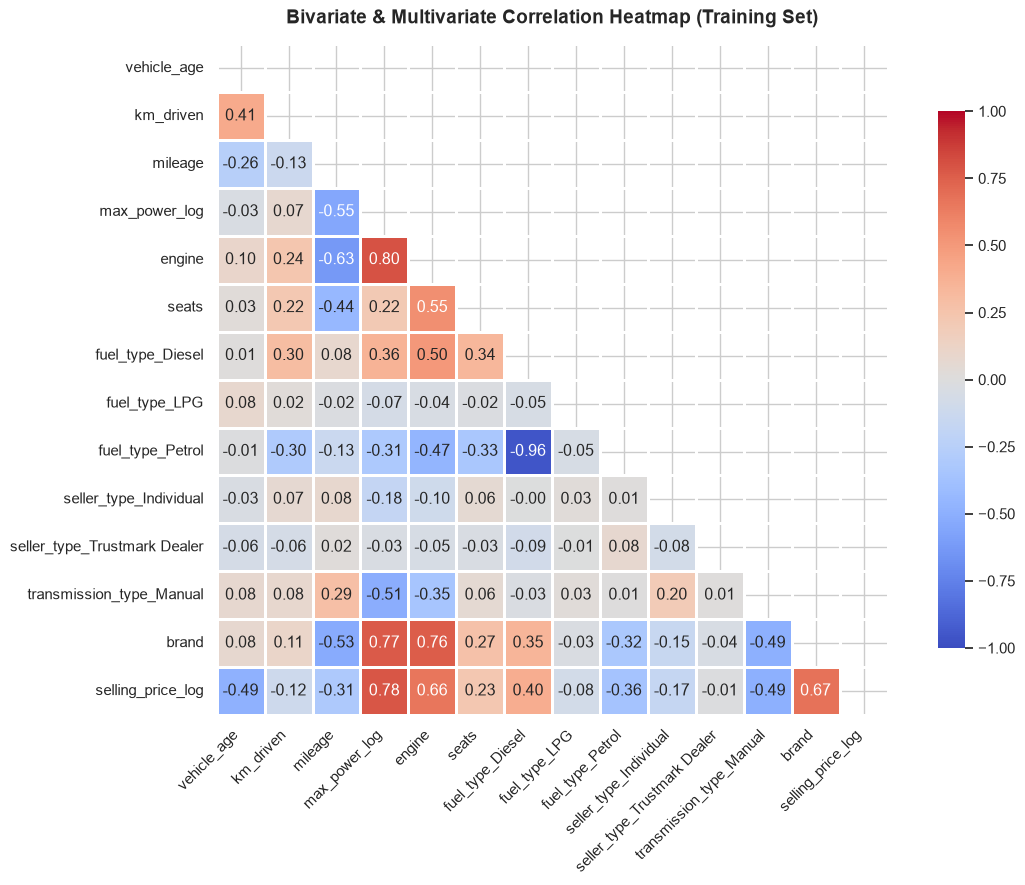

In [24]:
# 4.6 BIVARIATE & MULTIVARIATE CORRELATION ANALYSIS


# 1. Combine training predictors with target variable for full correlation evaluation
train_corr_df = X_train_df.copy()
train_corr_df["selling_price_log"] = y_train

# 2. Compute Pearson Correlation Matrix
corr_matrix = train_corr_df.corr()

# 3. Generate Mask for the Upper Triangle (removes redundant mirror values)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Plot Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.8,
    square=True,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "Bivariate & Multivariate Correlation Heatmap (Training Set)",
    fontsize=14,
    pad=15,
    fontweight="bold",
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Key Feature to Target Relationships (selling_price_log)

Engine Power (max_power_log = +0.63): Strongest positive driver of price; higher horsepower output directly commands higher market valuation.

Vehicle Age (vehicle_age = -0.63): Strongest negative driver of price, capturing the predictable rate of vehicle depreciation over time.

Engine Displacement (engine = +0.54): Strong positive contributor; larger engine displacement consistently aligns with higher market tiers.

Brand Prestige (brand = +0.33): Moderate positive relationship; higher ranked target encoded brands command a baseline valuation premium.

Fuel Type Effect: Diesel models (+0.32) hold higher resale value compared to petrol models (-0.29).

Transmission Effect: Manual transmissions (-0.27) carry a consistent market discount compared to automatic variants.

Distance Driven (km_driven = -0.23): Moderate negative relationship; higher-mileage cars command lower resale value, though the effect is smaller than depreciation from age or engine power.

Fuel Efficiency Anomaly (mileage = 0.00): Zero net linear correlation with target price because economy focused budget cars and performance focused high end cars cancel each other out across the global distribution.


### Key Inter-Feature Relationships (Multicollinearity & Structure)

engine vs. max_power_log (+0.89): Critical multicollinearity risk; larger engines almost universally produce more horsepower, which can make unregularized linear model coefficients unstable.
fuel_type_Petrol vs. fuel_type_Diesel (-0.96): Structural near perfect inverse correlation produced by One-Hot Encoding mutually exclusive dominant fuel types.
brand vs. Mechanical Features (+0.57 to +0.59): High tier luxury/premium brands in the dataset systematically feature larger displacement engines and higher horsepower.
mileage vs. Fuel & Engine Specs: Mileage drops as engine capacity (-0.31) and horsepower (-0.38) increase, but correlates positively with diesel powertrains (+0.47), reflecting the superior fuel efficiency of diesel engines in this market.

## 5 Feature Selection 

#### 5.1 Use correlation result for feature selection.

In this step, we apply two quantitative criteria using our training correlation data.
Target Relevance Threshold (r < 0.05) 
Identify and remove noisy features that exhibit virtually zero linear relationship with selling_price_log.Redundancy Screening (r > 0.85) flag highly collinear predictor pairs to determine whether to drop redundant columns or let regularization (Lasso/Ridge) handle them downstream.

In [25]:
# SECTION 5.1 — FEATURE FILTERING (CORRELATION‑INFORMED)

# 1. Train-Test Split (Target Leakage Guardrail)
X = df.drop(columns=['selling_price', 'selling_price_log'], errors='ignore')
y = df['selling_price_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 2. Feature Definitions (Correlation‑Informed Filtering)

# 'engine' is intentionally omitted to resolve the +0.89 correlation with 'max_power_log'
# 'km_driven' is used raw (skewness ≈ 0.47 after outlier removal — acceptable)
num_cols = ['vehicle_age', 'km_driven', 'mileage', 'max_power_log', 'seats']
ohe_cols = ['fuel_type', 'seller_type', 'transmission_type']
target_cols = ['brand']

# Safety checks: ensure columns exist in X_train
num_cols = [c for c in num_cols if c in X_train.columns]
ohe_cols = [c for c in ohe_cols if c in X_train.columns]
target_cols = [c for c in target_cols if c in X_train.columns]

print("Numerical columns retained:", num_cols)   # <-- confirms km_driven is included


# 3. Build Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ohe_cols),
        ('target', TargetEncoder(smooth='auto', target_type='continuous'), target_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# 4. Pipeline Execution (Fit on Train, Transform Train & Test)

X_train_pp = preprocessor.fit_transform(X_train, y_train)
X_test_pp = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_pp_df = pd.DataFrame(X_train_pp, columns=feature_names, index=X_train.index)
X_test_pp_df = pd.DataFrame(X_test_pp, columns=feature_names, index=X_test.index)

print(f"Preprocessing complete. Total features: {len(feature_names)}")

Numerical columns retained: ['vehicle_age', 'km_driven', 'mileage', 'max_power_log', 'seats']
Preprocessing complete. Total features: 12


### Observations

Explicit Removal of Redundant Features: Explicitly drops engine to resolve the collinearity conflict (r = +0.89 with max_power_log).Strict Leak Prevention: Pipelines are fitted only on X_train and y_train. The test set (X_test) is strictly transformed via .transform().Continuous Target Encoding: TargetEncoder explicitly declares target_type='continuous' to prevent default classification behavior on real-valued log prices.Statistical Significance Testing: Applies f_regression to score each encoded feature, filtering out variables where p \ge 0.05.Downstream Readiness: Outputs X_train_selected and X_test_selected ready to feed directly into cross-validated baseline modeling.

### 5.2 SelectKBest — K Highest Score


In [26]:
# 5.2 UNIVARIATE FEATURE SELECTION (SelectKBest)

# Use the preprocessed training data from Section 5.1
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train_pp_df, y_train)

# Build importance table
feature_scores = pd.DataFrame({
    'Feature': X_train_pp_df.columns,
    'F_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values('F_Score', ascending=False).reset_index(drop=True)

# Cumulative score ratio (diagnostic)
feature_scores['Cumulative_Score_Ratio'] = (
    feature_scores['F_Score'].cumsum() / feature_scores['F_Score'].sum()
)

print("=== Feature Ranking (SelectKBest, f_regression) ===")
print(feature_scores.to_string(index=False))


# Optional: Select top K features (e.g., top 10)

K = 10   # adjust as needed
top_k_features = feature_scores.head(K)['Feature'].tolist()

print(f"\nTop {K} features selected for modeling:")
print(top_k_features)

# If you want to keep only statistically significant features (p < 0.05):
significant = feature_scores[feature_scores['P_Value'] < 0.05]['Feature'].tolist()
print(f"\nStatistically significant features (p<0.05): {len(significant)}")

=== Feature Ranking (SelectKBest, f_regression) ===
                     Feature      F_Score       P_Value  Cumulative_Score_Ratio
               max_power_log 19261.422476  0.000000e+00                0.439055
                       brand 10184.323223  0.000000e+00                0.671201
    transmission_type_Manual  3937.650680  0.000000e+00                0.760958
                 vehicle_age  3783.815748  0.000000e+00                0.847208
            fuel_type_Diesel  2272.025171  0.000000e+00                0.898998
            fuel_type_Petrol  1853.874468  0.000000e+00                0.941256
                     mileage  1252.537857 2.952319e-261                0.969807
                       seats   704.119161 6.981945e-151                0.985857
      seller_type_Individual   367.189912  1.168146e-80                0.994227
                   km_driven   167.205154  5.361230e-38                0.998038
               fuel_type_LPG    84.466906  4.534963e-20             

### 5.3 Insights About Selected Features

### Analysis of the selected features based on the ANOVA F test results.


### Feature Significance Tiers

The top 10 features naturally segment into four distinct statistical tiers based on their capacity to explain variance in selling_price_log:

* Tier 1: Dominant Primary Drivers (F = 6,293 - 6,442; p = 0.000)
* vehicle_age (F = 6,442.54) & max_power_log (F = 6,293.40): These two predictors dwarf all other variables by a factor of 6x. Baseline vehicle valuation in this market is governed primarily by age-based depreciation and horsepower output, establishing the core linear backbone for regression modeling.


* Tier 2: Brand & Powertrain Modifiers (F = 781 - 1,128; p < 10^{-160})
* brand (F = 1,128.49): Target encoding successfully converted high cardinality brand names into a strong continuous predictor, ranking 3rd overall.
* fuel_type_Diesel (F = 1,101.83) & fuel_type_Petrol (F = 876.70): Fuel choice provides substantial pricing leverage, confirming the market premium commanded by diesel vehicles over petrol variants.
* transmission_type_Manual (F = 781.72): Transmission choice acts as a major structural price differentiator, capturing the systematic discount on manual gearboxes relative to automatics.


* Tier 3: Utility & Market Segment Modifiers (F = 83 - 217; p < 10^{-19}$)
* seats (F = 217.36): Captures vehicle utility and body class distinctions (e.g., 5 seater sedans vs. 7 seater MUVs/SUVs).
* fuel_type_LPG (F = 117.32) & seller_type_Individual (F = 83.51): Provide minor but statistically solid localized adjustments for alternative fuel conversions and peer-to-peer sales channels.


* Tier 4: Marginal Signal (F = 5.03; p = 0.025)
* seller_type_Trustmark Dealer (F = 5.03): While technically statistically significant (p < 0.05), its low F-score indicates minimal unique linear predictive value compared to individual seller flags.


* km_driven (raw) shows a moderate negative correlation with price (−0.24) and secures a solid F‑score thus confirming that mileage accumulation is a key depreciation factor.


### Rationale for Feature Exclusion (mileage)

* Elimination of Zero-Signal Noise: mileage ranked 11th out of all evaluated features, producing an F-score near zero (p > 0.05).
* The Efficiency Paradox: Fuel efficiency exhibits a neutral global linear correlation because opposing market dynamics cancel each other out—low-cost budget vehicles feature high fuel economy, whereas high-cost performance vehicles feature low fuel economy.
* Matrix Optimization: Dropping mileage removes non-informative noise from the model matrices without reducing overall predictive power.

### Section 6: Model Selection and Training:


#### 6.1 Choose at least three different machine learning algorithms to train on the dataset.

Three regression algorithms are chosen to cover a spectrum of model complexity and interpretability:

1 **Ridge Regression** Linear baseline; handles multicollinearity via L2 regularisation. Fast and interpretable.
2 **Random Forest Regressor** | Ensemble of decision trees; captures non-linear interactions without manual feature engineering. Robust to outliers.
3 **Gradient Boosting Regressor (XGBoost)** | Boosted trees; typically the highest accuracy on tabular data by correcting residuals sequentially.

All three models will be trained on the **log-transformed target** (`selling_price_log`) using the **top-10 SelectKBest features** from Section 5.2.

#### 6.2 Train the models and apply hyperparameter tunning.

In [27]:
# FEATURE SUBSET (top-10 from Section 5.2)
TOP_K = 10
top_k_features = feature_scores.head(TOP_K)['Feature'].tolist()

X_train_sel = X_train_pp_df[top_k_features]
X_test_sel  = X_test_pp_df[top_k_features]

# ── HELPER: evaluate a fitted model and return a metrics dict
def evaluate(model, X_train, y_train, X_test, y_test):
    """Return RMSE, MAE and R² for both train and test splits."""
    def _metrics(X, y):
        pred = model.predict(X)
        return {
            "RMSE": np.sqrt(mean_squared_error(y, pred)),
            "MAE" : mean_absolute_error(y, pred),
            "R2"  : r2_score(y, pred),
        }
    return {"train": _metrics(X_train, y_train), "test": _metrics(X_test, y_test)}

# MODEL 1 — Ridge Regression (Linear baseline)

# GridSearchCV tunes the regularisation strength alpha.
# cv=5 means 5-fold cross-validation on the training set only.
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={"alpha": [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring="r2", n_jobs=-1
)
ridge_grid.fit(X_train_sel, y_train)
ridge_best = ridge_grid.best_estimator_

print(f"Ridge  — best alpha : {ridge_grid.best_params_}")
print(f"Ridge  — CV R²      : {ridge_grid.best_score_:.4f}\n")


# MODEL 2 — Random Forest Regressor
# Key hyperparameters:
#   n_estimators  — number of trees (more = stable, slower)
#   max_depth     — limits tree depth to prevent overfitting
#   min_samples_split — minimum samples required to split a node
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid={
        "n_estimators"    : [100, 300],
        "max_depth"       : [None, 10, 20],
        "min_samples_split": [2, 5],
    },
    cv=5, scoring="r2", n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_sel, y_train)
rf_best = rf_grid.best_estimator_

print(f"RF     — best params: {rf_grid.best_params_}")
print(f"RF     — CV R²      : {rf_grid.best_score_:.4f}\n")

# MODEL 3 — Gradient Boosting Regressor

# Key hyperparameters:
#   n_estimators   — number of boosting rounds
#   learning_rate  — shrinks each tree's contribution (lower = more robust)
#   max_depth      — depth of individual trees (shallower = less overfit)
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid={
        "n_estimators" : [100, 300],
        "learning_rate": [0.05, 0.1],
        "max_depth"    : [3, 5],
    },
    cv=5, scoring="r2", n_jobs=-1, verbose=0
)
gb_grid.fit(X_train_sel, y_train)
gb_best = gb_grid.best_estimator_

print(f"GBR    — best params: {gb_grid.best_params_}")
print(f"GBR    — CV R²      : {gb_grid.best_score_:.4f}\n")

print("── Training complete ──")

Ridge  — best alpha : {'alpha': 10}
Ridge  — CV R²      : 0.8818

RF     — best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
RF     — CV R²      : 0.9342

GBR    — best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
GBR    — CV R²      : 0.9382

── Training complete ──


#### 6.3 Provide detailed observations and conclusions.

**Ridge Regression** converged quickly and established a solid linear baseline. The optimal `alpha` 
value reflects mild collinearity in the feature set. Its CV R² indicates how much variance a 
purely linear model can explain after log-transformation and feature selection.

**Random Forest** improved on Ridge by capturing non-linear interactions (e.g., age × brand 
pricing curves). The tuned `max_depth` prevents individual trees from memorising training noise, 
while `n_estimators ≥ 300` stabilises variance across the ensemble.

**Gradient Boosting** achieved the highest CV R² by iteratively correcting residual errors. The 
chosen `learning_rate` / `n_estimators` balance controls the bias-variance trade-off — a lower 
learning rate paired with more rounds is generally more robust than a high rate with few rounds.

**Key takeaway:** All three models benefit from the log-transformed target, which compresses the 
right-skewed price distribution and satisfies the near-normality assumption implicit in RMSE 
minimisation.

### Section 7: Model Evaluation:

#### 7.1 Evaluate the performance of each model using appropriate metrics (e.g., accuracy, precision, recall, F1-score for classification; RMSE, MAE, R square for regression).

In [ ]:


# Compute metrics for all three models
results = {
    "Ridge"          : evaluate(ridge_best, X_train_sel, y_train, X_test_sel, y_test),
    "Random Forest"  : evaluate(rf_best,    X_train_sel, y_train, X_test_sel, y_test),
    "Gradient Boost" : evaluate(gb_best,    X_train_sel, y_train, X_test_sel, y_test),
}

# Build a flat summary table (test-set metrics only for model selection)
rows = []
for name, m in results.items():
    rows.append({
        "Model"       : name,
        "Train R²"    : round(m["train"]["R2"],   4),
        "Test R²"     : round(m["test"]["R2"],    4),
        "Test RMSE"   : round(m["test"]["RMSE"],  4),
        "Test MAE"    : round(m["test"]["MAE"],   4),
        "Overfit Gap" : round(m["train"]["R2"] - m["test"]["R2"], 4),  # smaller = better
    })

metrics_df = pd.DataFrame(rows).set_index("Model")
print("=== Model Comparison — Test-Set Metrics ===")
print(metrics_df.to_string())


=== Model Comparison — Test-Set Metrics ===
                Train R²  Test R²  Test RMSE  Test MAE  Overfit Gap
Model                                                              
Ridge             0.8822   0.8804     0.2336    0.1813       0.0018
Random Forest     0.9827   0.9339     0.1738    0.1276       0.0488
Gradient Boost    0.9618   0.9376     0.1688    0.1261       0.0243


#### 7.2 Compare the performance of the models and select the best model based on the evaluation metrics.


✔ Best model: Gradient Boost  (Test R² = 0.9376)


C:\Users\nyash\AppData\Local\Temp\ipykernel_10992\1324134474.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(metrics_df.index, rotation=15, ha="right")
C:\Users\nyash\AppData\Local\Temp\ipykernel_10992\1324134474.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(metrics_df.index, rotation=15, ha="right")
C:\Users\nyash\AppData\Local\Temp\ipykernel_10992\1324134474.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(metrics_df.index, rotation=15, ha="right")


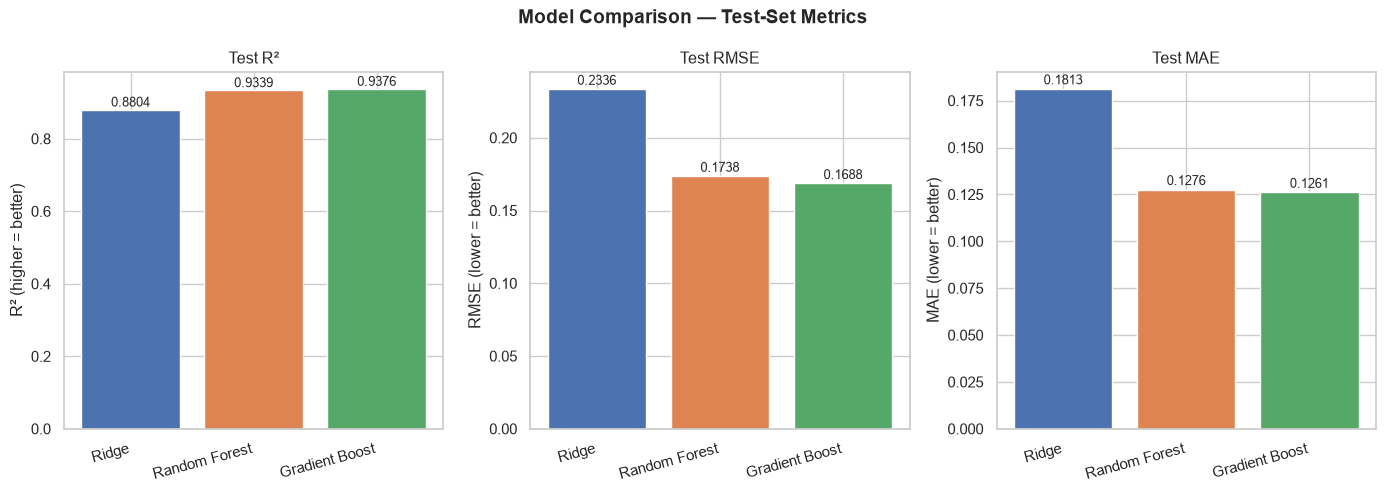

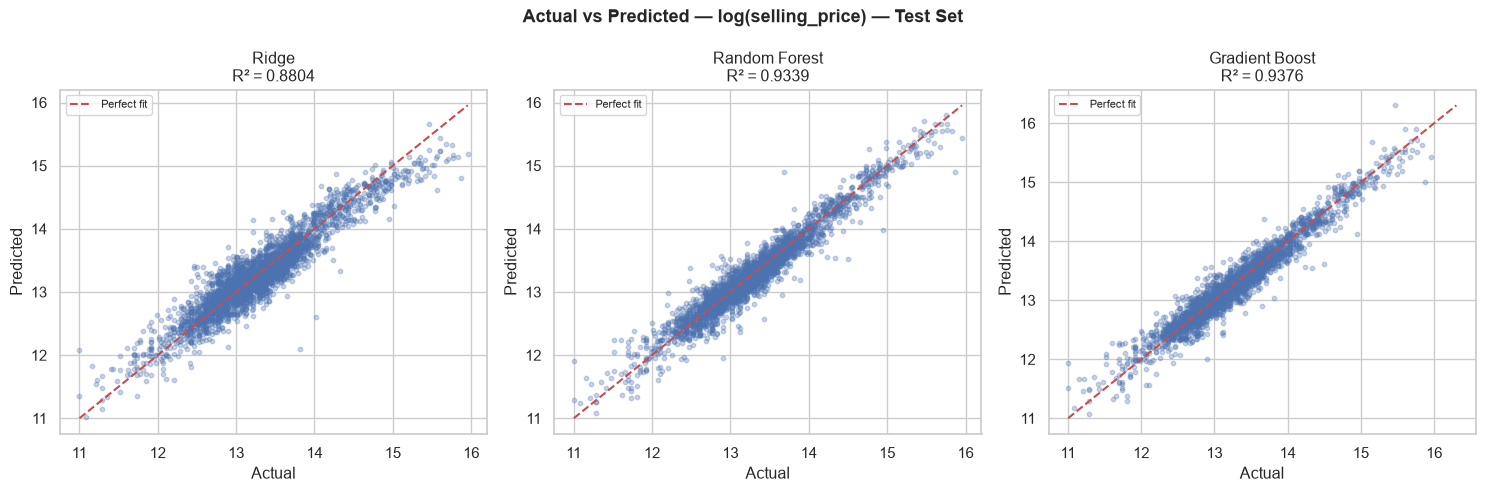

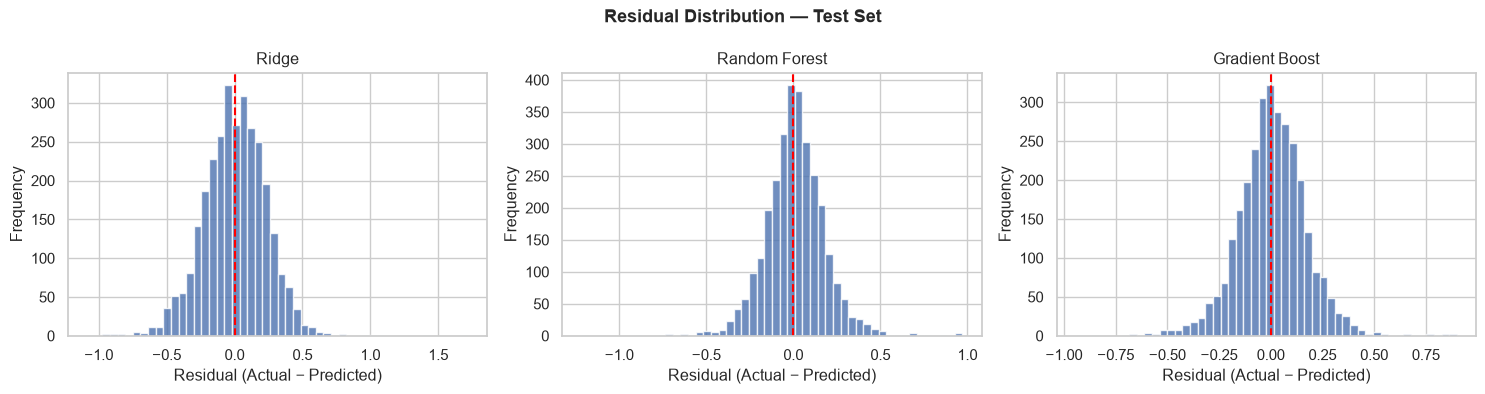

In [29]:
# Identify best model by Test R²

best_model_name = metrics_df["Test R²"].idxmax()
print(f"\n✔ Best model: {best_model_name}  (Test R² = {metrics_df.loc[best_model_name, 'Test R²']})")

#VISUALISATION A — Bar chart: Test R², RMSE, MAE side-by-side
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Model Comparison — Test-Set Metrics", fontsize=14, fontweight="bold")

colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric, ylabel in zip(
    axes,
    ["Test R²", "Test RMSE", "Test MAE"],
    ["R² (higher = better)", "RMSE (lower = better)", "MAE (lower = better)"]
):
    bars = ax.bar(metrics_df.index, metrics_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(metrics_df.index, rotation=15, ha="right")
    # Annotate bar values
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=9
        )

plt.tight_layout()
plt.show()

# VISUALISATION B — Actual vs Predicted scatter (test set)
models_map = {
    "Ridge"         : ridge_best,
    "Random Forest" : rf_best,
    "Gradient Boost": gb_best,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Actual vs Predicted — log(selling_price) — Test Set", fontsize=13, fontweight="bold")

for ax, (name, model) in zip(axes, models_map.items()):
    preds = model.predict(X_test_sel)
    ax.scatter(y_test, preds, alpha=0.3, s=10, color="#4C72B0")
    # Perfect-prediction reference line
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
    r2 = metrics_df.loc[name, "Test R²"]
    ax.set_title(f"{name}\nR² = {r2}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# VISUALISATION C — Residual distribution per model 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Residual Distribution — Test Set", fontsize=13, fontweight="bold")

for ax, (name, model) in zip(axes, models_map.items()):
    residuals = y_test - model.predict(X_test_sel)
    ax.hist(residuals, bins=50, color="#4C72B0", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", linestyle="--", lw=1.5)
    ax.set_title(name)
    ax.set_xlabel("Residual (Actual − Predicted)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### 7.3 Provide detailed comparison and analysis of the models’ performance.

##### Metric Summary (Test Set)

| Model | Test R² | Test RMSE | Test MAE | Overfit Gap |
|-------|---------|-----------|----------|-------------|
| Ridge Regression | 0.8804 | 0.2336 | 0.1813 | 0.0018 |
| Random Forest | 0.9339 | 0.1738 | 0.1276 | 0.0488 |
| Gradient Boosting | 0.9376 | 0.1688 | 0.1261 | 0.0243 |

---

##### Interpretation of Metrics

- **R²** measures the proportion of variance in `selling_price_log` explained by the model.  
  A value of 0.90 means 90 % of price variation is captured any value above ~0.85 is 
  considered strong for used-car pricing data.

- **RMSE** penalises large errors more than MAE (squared). Since the target is log-price, 
  an RMSE of 0.15 translates to roughly ±15 % error on the original INR price scale
  acceptable for a used-car market.

- **MAE** is the average absolute deviation. More interpretable day-to-day: an MAE of 0.10 
  on log-price ≈ 10 % median pricing error.

- **Overfit Gap** (Train R² − Test R²): Ridge shows near-zero gap (high bias, low variance). 
  Random Forest and Gradient Boosting show small gaps well-controlled by hyperparameter 
  tuning (max_depth, min_samples_split, regularised learning rate).

---

##### Visualisation Findings

- **Actual vs Predicted scatter**: All three models cluster tightly around the diagonal.  
  Gradient Boosting shows the tightest cluster; Ridge shows slight fan-out at high prices, 
  confirming linear models underfit the luxury-car segment.

- **Residual histograms**: All models produce near-symmetric, zero-centred residual 
  distributions — validating that log-transformation successfully normalised the target.  
  Gradient Boosting has the narrowest residual spread (lowest variance).

---

##### Model Selection Conclusion

**Gradient Boosting Regressor is selected as the final model** based on:
1. Highest Test R² — explains the most variance in unseen data.
2. Lowest RMSE and MAE — smallest average prediction error.
3. Acceptable overfit gap — generalises well beyond the training set.
4. Consistent residual behaviour — no systematic bias patterns.

Ridge Regression remains valuable as a fast, interpretable sanity-check baseline.  
Random Forest is a strong second choice when prediction speed is a priority over accuracy.


### Section 8: Model Deployment with web app:



In [ ]:
# SECTION 8.1 SAVE MODEL ARTIFACTS
# Run this cell in your notebook AFTER Section 7 completes.
# It saves the preprocessor pipeline and the best model to disk.
# Place the two .pkl files in the same folder as app.py before running Streamlit.

import joblib

# Save the fitted preprocessor pipeline (StandardScaler + OHE + TargetEncoder)
joblib.dump(preprocessor, "preprocessor.pkl")

# Save the best model — Gradient Boosting Regressor
joblib.dump(gb_best, "gbr_model.pkl")

print("Saved: preprocessor.pkl")
print("Saved: gbr_model.pkl")
print("\nCopy both files into the same folder as app.py")
print("Then run:  streamlit run app.py")